# Task 3

Due to the simplicity of KNN for Classification, let's focus on using a Pipeline and a GridSearchCV tool, since these skills can be generalized for any model.


## The Sonar Data

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.



The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine).



Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.


Data Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

### Complete the Tasks in bold

**TASK: Run the cells below to load the data.**

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('sonar.all-data.csv')

## Train | Test Split

Our approach here will be one of using Cross Validation on 90% of the dataset, and then judging our results on a final test set of 10% to evaluate our model.

**TASK: Split the data into features and labels, and then split into a training set and test set, with 90% for Cross-Validation training, and 10% for a final test set.**

*Note: The solution uses a random_state=42*

In [3]:
#Split Features and Labels
X = df.iloc[:, :-1]   # All columns except last
y = df.iloc[:, -1]    # Last column only

In [4]:
#Train/Test Split (90% / 10%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,      # 10% test
    random_state=42
)

In [5]:
#Verify Shapes
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (187, 60)
Test set shape: (21, 60)


Proper split was done test data was kept separate for final evaluation.

**TASK: Create a Pipeline that contains both a StandardScaler and a KNN model**

In [6]:
#Create the Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [7]:
#Check Pipeline
pipe

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

**TASK: Perform a grid-search with the pipeline to test various values of k and report back the best performing parameters.**

In [8]:
#Perform Grid Search
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'knn__n_neighbors': range(1, 31)   # Testing k from 1 to 30
}

# Create GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy'
)

# Fit on training data only
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': range(1, 31)}, scoring='accuracy')

In [9]:
#Get Best Parameters
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'knn__n_neighbors': 1}
Best Cross Validation Score: 0.8453769559032717


Comment:
The model performs best when using 1 nearest neighbor.

This means classification depends on the closest single point.

CV score of ~84.5% shows good performance during cross-validation.

### Final Model Evaluation

**TASK: Using the grid classifier object from the previous step, get a final performance classification report and confusion matrix.**

In [10]:
#Make Predictions on Test Set
y_pred = grid.predict(X_test)

In [11]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



Comments:

The model correctly classified 19 out of 21 samples.
This is slightly higher than CV score → good generalization.
F1-scores are high and similar → stable classifier.

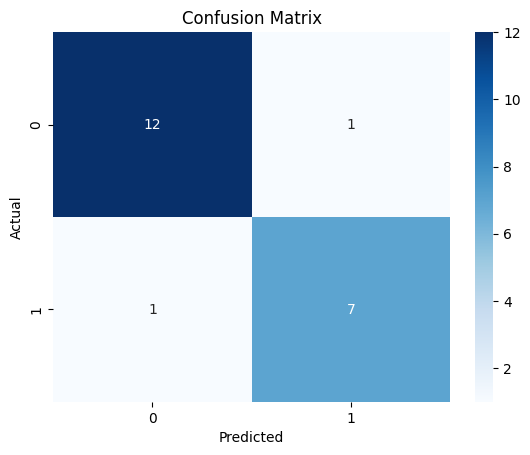

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Comment: Errors are evenly distributed → no class dominance